In [5]:
!pip install langgraph

!pip install langgraph

In [8]:
!pip install langchain

In [9]:
!pip install google-generativeai

  Using cached google_generativeai-0.8.6-py3-none-any.whl.metadata (3.9 kB)
  Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl.metadata (5.7 kB)
  Using cached google_api_core-2.30.1-py3-none-any.whl.metadata (3.1 kB)
  Using cached google_api_python_client-2.193.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached proto_plus-1.27.2-py3-none-any.whl.metadata (2.2 kB)
  Using cached googleapis_common_protos-1.73.1-py3-none-any.whl.metadata (9.2 kB)
  Using cached httplib2-0.31.2-py3-none-any.whl.metadata (2.2 kB)
  Using cached google_auth_httplib2-0.3.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached uritemplate-4.2.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached grpcio_status-1.80.0-py3-none-any.whl.metadata (1.3 kB)
INFO: pip is looking at multiple versions of grpcio-status to determine which version is compatible with other requirements. This could take a while.
  Using cached grpcio_status-1.78.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached grpcio_status-

In [10]:
!pip install dotenv


  Using cached dotenv-0.9.9-py2.py3-none-any.whl.metadata (279 bytes)
Using cached dotenv-0.9.9-py2.py3-none-any.whl (1.9 kB)


In [8]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [24]:
# define state
class BMIState(TypedDict):

  weight_kg:float
  height_m:float
  bmi:float
  category:str

In [25]:
def calculate_bmi(state:BMIState)->BMIState:

  weight=state['weight_kg']
  height=state['height_m']

  bmi=weight/(height**2)

  state['bmi']=round(bmi,2)

  return state

In [26]:
def label_bmi(state:BMIState)->BMIState:

  bmi=state['bmi']

  if bmi<18.5:
    state['category']='underweight'
  elif 18.5<=bmi<25:
    state['category']='normal'
  elif 25<=bmi<30:
    state['category']='overweight'
  else:
    state['category']='obese'

  return state

In [27]:
# define your graph

graph=StateGraph(BMIState)

# add nodes to your graph 

graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('label_bmi',label_bmi)

# add edges to your graph

graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','label_bmi')
graph.add_edge('label_bmi',END)

# compile the graph

workflow=graph.compile()



In [28]:
# execute the graph 

final_state=workflow.invoke({'weight_kg':80,'height_m':1.75})


print(final_state)

{'weight_kg': 80, 'height_m': 1.75, 'bmi': 26.12, 'category': 'overweight'}


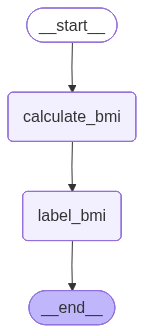

In [21]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())